# 230 — Blob clustering

Blob feature extraction → score gating → KMeans (K-sweep) + Hierarchical clustering on the gated, weighted blob feature matrix `Xw`.

Outputs land in `outputs/clustering/{kmeans,hierarchical}/blob/runs/<timestamp>/` via `lf_cluster_run.fit_and_save`.
Each run writes: model.joblib, predictor.joblib, X_train.npy, labels.csv, metrics.json, manifest.json, plus standard figures (centroids, silhouette per cluster, similarity heatmap, centroid distance heatmap).

Per-cluster mean-ERSP thumbnails (`cluster_centroids/cluster_<NN>.png`) are written by the final BACKFILL_CENTROIDS cell so the MOBA cluster-chip thumbnails light up automatically.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from functions import lf_blob_clustering_config as cfg
from functions.lf_blob_clustering import (
    s20_build_valley_features,
    s30_gate_by_blob_score,
    q31_plot_score_histograms,
    q32_plot_score_gating_grid,
    q33_plot_valley_overlay_grid,
)
from functions.lf_blob_metrics import s22_build_blob_feature_matrix, s23_init_blob_metric
from functions.lf_clustering import s10_load_ersps
from functions import lf_cluster_run as R

SCRIPT_NAME = '230_blob_clustering.ipynb'


## Config

In [2]:
# ── data input ───────────────────────────────
INPUT_DIR = Path('\\\\nasac-m2.unige.ch\\m-HumanNeuronLab\\ANALYSIS\\FLM\\Analysis_LoraFanda\\01_FBM_Analysis\\outputs\\04_ersp_LM_RAWONLY')
TASK      = 'LM'
CONDITIONS = ('audio', 'picture', 'reading')
N_FREQ, N_TIME = 129, 300

# ── segmentation ───────────────────────────────
VALLEY_PARAMS = cfg.VALLEY_PARAMS

# ── score gating ───────────────────────────────
BLOB_SCORE_QUANTILE  = cfg.BLOB_SCORE_QUANTILE
MANUAL_SCORE_THR     = None   # set a float to override quantile

# ── feature weighting ───────────────────────────
FEATURE_TYPE_WEIGHTS = cfg.FEATURE_TYPE_WEIGHTS

# ── clustering (orchestrator handles save layout) ──────────────────
# Sweep KMeans across multiple K so silhouette can pick the best.
# Same range as 210 raw clustering for cross-feature-set comparison.
KMEANS_K_RANGE = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

# Hierarchical: single K cut. Keep the same K as the best KMeans K below.
HC_METHOD      = 'average'      # 'average' | 'complete' | 'ward'
HC_METRIC      = 'euclidean'    # only used with non-ward linkages
HC_N_CLUSTERS  = 10             # cut HC at this K (matches mid of KMEANS_K_RANGE)
RANDOM_STATE   = cfg.RANDOM_STATE

print('VALLEY_PARAMS:', VALLEY_PARAMS)
print('BLOB_SCORE_QUANTILE:', BLOB_SCORE_QUANTILE)
print('KMEANS_K_RANGE:', KMEANS_K_RANGE)


VALLEY_PARAMS: {'thr_pos': 2.5, 'thr_neg': -3.5, 'delta_valley': 1.5, 'min_mean_pos': 1.75, 'max_mean_neg': -2.8000000000000003, 'max_blobs': 6, 'sign_mode': 'both'}
BLOB_SCORE_QUANTILE: 0.9
KMEANS_K_RANGE: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## 1 — Load ERSPs

In [3]:
df_meta, ersp_list = s10_load_ersps(
    input_dir=INPUT_DIR,
    task=TASK,
    allowed_conditions=CONDITIONS,
    n_freq=N_FREQ,
    n_time=N_TIME,
)
print(df_meta.shape, len(ersp_list))
df_meta.head()

Detected patient folders:
  - EL030
  - EL035
  - EL037
  - EL038
  - EL040
  - EL042
  - EL043
  - EL044
  - EL045
  - PAT_2868
  - PAT_3066
  - PAT_3301
  - PAT_3390
  - PAT_3415
  - PAT_3455
  - PAT_3780
  - PAT_3965
  - PAT_3975
  - PAT_5515
  - PAT_5533
  - PAT_6684
  - PAT_6704
  - PAT_6854

Total patients detected: 23

Patient EL030 — conditions found: ['audio', 'picture', 'reading']
  Loading 96 files from condition 'audio'
  Loading 96 files from condition 'picture'
  Loading 96 files from condition 'reading'

Patient EL035 — conditions found: ['audio', 'picture', 'reading']
  Loading 113 files from condition 'audio'
  Loading 113 files from condition 'picture'
  Loading 113 files from condition 'reading'

Patient EL037 — conditions found: ['audio', 'picture', 'reading']
  Loading 95 files from condition 'audio'
  Loading 95 files from condition 'picture'
  Loading 95 files from condition 'reading'

Patient EL038 — conditions found: ['audio', 'picture', 'reading']
  Loading 78

,sample_idx,patient_id,condition,task,electrode,file_path
0,0,EL030,audio,LM,A_L10,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
1,1,EL030,audio,LM,A_L11,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
2,2,EL030,audio,LM,A_L12,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
3,3,EL030,audio,LM,A_L13,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
4,4,EL030,audio,LM,A_L14,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...


## 2 — Valley blob segmentation + feature extraction

In [4]:
X_blob, max_scores, blobs_per_sample = s22_build_blob_feature_matrix(
    ersp_list=ersp_list,
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    thr_pos=float(VALLEY_PARAMS['thr_pos']),
    thr_neg=float(VALLEY_PARAMS['thr_neg']),
    delta_valley=float(VALLEY_PARAMS['delta_valley']),
    min_mean_pos=float(VALLEY_PARAMS['min_mean_pos']),
    max_mean_neg=float(VALLEY_PARAMS['max_mean_neg']),
    sign_mode=str(VALLEY_PARAMS['sign_mode']),
)
print('X_blob:', X_blob.shape)
print('max_scores:', max_scores.shape, '  min/max:', max_scores.min(), max_scores.max())

Valley-blob feature matrix: X_blob.shape=(7268, 48) (max_blobs=6, features_per_blob=8)
X_blob: (7268, 48)
max_scores: (7268,)   min/max: 0.0 78550.984


## 2b — Per-sample alternate views (BLOB + minus101 PNGs)

Walks every sample in `ersp_list` and writes two extra PNGs alongside the existing `ERSP_clean/*_CLEAN.png`:

* `ERSP_blob/<cond>/<stem>_BLOB.png` — transparent ERSP centroid + thick blob-feature overlays
* `ERSP_minus101/<cond>/<stem>_M101.png` — painted -1/0/+1 segmentation

Both lit live under `01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY/<pid>/LM/<sub>/<cond>/`. The MOBA samples pane has a 3-way toggle that swaps `img.src` from `ERSP_clean/*_CLEAN.png` to either of these.

Idempotent: skips samples whose target PNG already exists, so re-running 230 doesn't redo work.


In [5]:
# Per-sample BLOB + M101 PNG generation. Uses the full (ungated) ersp_list +
# blobs_per_sample so every sample (including those gated out of clustering)
# still gets an alternate-view PNG, which MOBA needs since the raw-clustering
# 210 keeps all samples.
from pathlib import Path as _PathPS
from functions.lf_blob_metrics import save_sample_blob_png
from functions.lf_minus101    import save_sample_minus101_png

GEN_ALT_VIEWS = True   # set False to skip this cell
FORCE_REGEN   = False  # True = overwrite existing PNGs; False = skip if file exists

def _alt_view_paths(file_path):
    """Map ERSP_matrix/<cond>/<stem>.npy -> the BLOB and M101 PNG paths."""
    p = str(file_path)
    if 'ERSP_matrix' not in p:
        return None, None
    blob_p = p.replace('/ERSP_matrix/', '/ERSP_blob/').replace('.npy', '_BLOB.png')
    m101_p = p.replace('/ERSP_matrix/', '/ERSP_minus101/').replace('.npy', '_M101.png')
    # print(blob_p)
    return _PathPS(blob_p), _PathPS(m101_p)

if not GEN_ALT_VIEWS:
    print('[skip] GEN_ALT_VIEWS = False — not writing per-sample BLOB + M101 PNGs')
else:
    n_total = len(ersp_list)
    n_blob_wrote = n_blob_skip = 0
    n_m101_wrote = n_m101_skip = 0
    n_bad = 0
    print(f'Writing per-sample BLOB + M101 PNGs for {n_total} samples...')
    for i in range(n_total):
        fp = df_meta.iloc[i]['file_path'] if 'file_path' in df_meta.columns else None
        if not fp:
            n_bad += 1; continue
        blob_path, m101_path = _alt_view_paths(fp)
        if blob_path is None:
            n_bad += 1; continue
        try:
            if FORCE_REGEN or not blob_path.exists():
                save_sample_blob_png(ersp_list[i], blobs_per_sample[i], blob_path)
                n_blob_wrote += 1
            else:
                n_blob_skip += 1
            if FORCE_REGEN or not m101_path.exists():
                save_sample_minus101_png(ersp_list[i], blobs_per_sample[i], m101_path)
                n_m101_wrote += 1
            else:
                n_m101_skip += 1
        except Exception as e:
            print(f'  [warn] sample {i}: {e}')
            n_bad += 1
        if (i + 1) % 200 == 0:
            print(f'  ...{i+1}/{n_total}')
    print(f'BLOB PNGs : wrote {n_blob_wrote}, skipped existing {n_blob_skip}')
    print(f'M101 PNGs : wrote {n_m101_wrote}, skipped existing {n_m101_skip}')
    if n_bad:
        print(f'  ({n_bad} samples without parseable file_path — skipped)')


Writing per-sample BLOB + M101 PNGs for 7268 samples...
  ...200/7268
  ...400/7268
  ...600/7268
  ...800/7268
  ...1000/7268
  ...1200/7268
  ...1400/7268
  ...1600/7268
  ...1800/7268
  ...2000/7268
  ...2200/7268
  ...2400/7268
  ...2600/7268
  ...2800/7268
  ...3000/7268
  ...3200/7268
  ...3400/7268
  ...3600/7268
  ...3800/7268
  ...4000/7268
  ...4200/7268
  ...4400/7268
  ...4600/7268
  ...4800/7268
  ...5000/7268
  ...5200/7268
  ...5400/7268
  ...5600/7268
  ...5800/7268
  ...6000/7268
  ...6200/7268
  ...6400/7268
  ...6600/7268
  ...6800/7268
  ...7000/7268
  ...7200/7268
BLOB PNGs : wrote 0, skipped existing 7268
M101 PNGs : wrote 0, skipped existing 7268


## 3 — Score gating

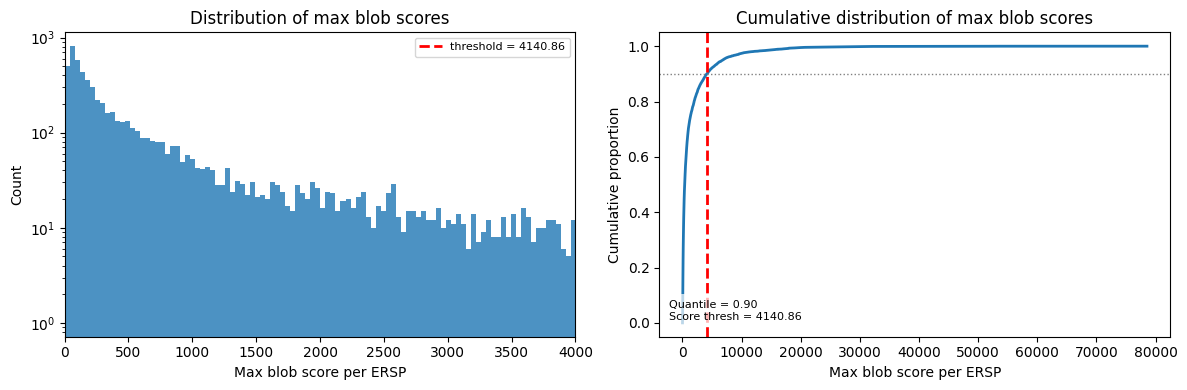

In [6]:
q31_plot_score_histograms(
    max_scores=max_scores,
    score_thresh=float(np.quantile(max_scores, BLOB_SCORE_QUANTILE)),
    quantile=BLOB_SCORE_QUANTILE,
)

In [7]:
(
    df_keep, ersp_keep, X_blob_keep,
    keep_idx, score_thr, keep_mask, drop_idx
) = s30_gate_by_blob_score(
    df_meta=df_meta.copy(),
    ersp_list=ersp_list,
    X_blob=X_blob,
    max_scores=max_scores,
    quantile=BLOB_SCORE_QUANTILE,
    manual_threshold=MANUAL_SCORE_THR,
)
print('Kept:', len(df_keep), '  Dropped:', len(drop_idx))

Score gating:
  quantile=0.90 → q_thresh=4140.857
  using score_thresh=4140.857 (from quantile)
  kept   : 727 ERSPs
  dropped: 6541 ERSPs
Kept: 727   Dropped: 6541


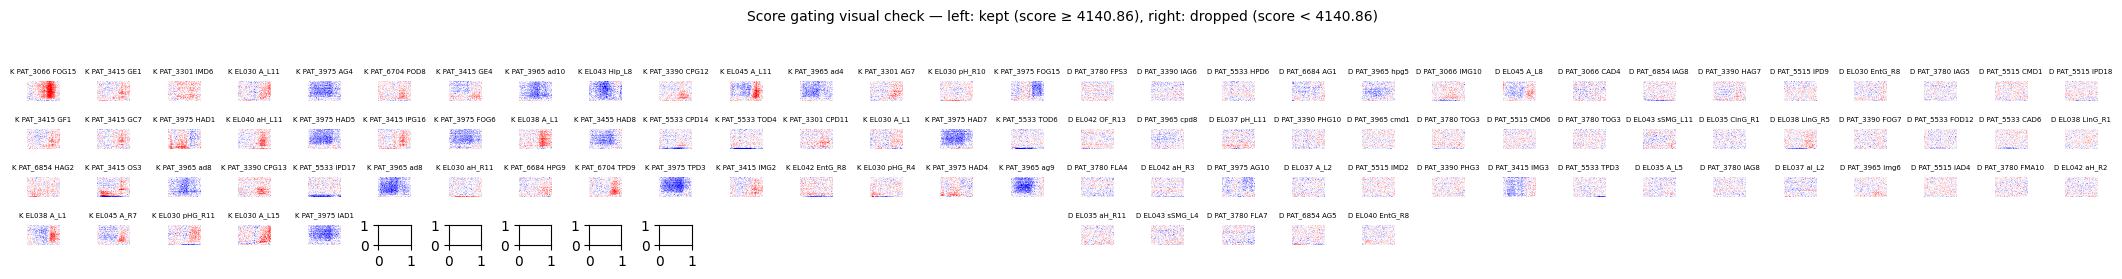

In [8]:
q32_plot_score_gating_grid(
    ersp_list_raw=ersp_list,
    df_meta_raw=df_meta,
    keep_idx=keep_idx,
    drop_idx=drop_idx,
    score_thresh=score_thr,
)

## 4 — Feature weighting

In [9]:
s23_init_blob_metric(
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    features_per_blob=8,
    feature_type_weights=FEATURE_TYPE_WEIGHTS,
)

# Build weight vector and apply
from functions.lf_blob_metrics import BLOB_WEIGHT_VEC
Xw = X_blob_keep * BLOB_WEIGHT_VEC
print('Xw:', Xw.shape)

[s23_init_blob_metric] 6 blobs × 8 features = 48D; weight_vec.shape=(48,)
Xw: (727, 48)


# Clustering

Two methods on the same `Xw` (weighted blob feature matrix): K-Means (with K sweep) and Hierarchical (Ward / average).
Each `fit_and_save` call writes a self-contained run directory and updates `outputs/clustering/index.json`.


In [10]:
# KMeans K-sweep on blob features.
manifest_km = R.fit_and_save(
    Xw,
    df_keep=df_keep,
    method='kmeans',
    feature_set='blob',
    params={'k_range': KMEANS_K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    method_label='K-Means',
    feature_set_label='Blob Features',
    notebook=SCRIPT_NAME,
)
BEST_K = manifest_km['summary']['best_k']
print(f'Best K (KMeans/blob, by silhouette): {BEST_K}')


  K= 10  sil=0.1589
  K= 11  sil=0.1554
  K= 12  sil=0.1565
  K= 13  sil=0.1637
  K= 14  sil=0.1574
  K= 15  sil=0.1618
  K= 16  sil=0.1641
  K= 17  sil=0.1706
  K= 18  sil=0.1681
  K= 19  sil=0.1710
  K= 20  sil=0.1652

[KMeans] Best K=19  silhouette=0.1710
[fit_and_save] kmeans/blob/20260522_205434
  n_samples=727 n_clusters=19 silhouette=0.171
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\blob\runs\20260522_205434
Best K (KMeans/blob, by silhouette): 19


In [11]:
# Hierarchical on blob features — K-sweep so MOBA can scrub. Best K (by silhouette)
# is the default cut in labels.csv; every K's labels also go into
# cluster_labels_by_k.csv (linkage_Z is computed once).
manifest_hc = R.fit_and_save(
    Xw,
    df_keep=df_keep,
    method='hierarchical',
    feature_set='blob',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'k_range': KMEANS_K_RANGE},
    method_label='Hierarchical',
    feature_set_label='Blob Features',
    notebook=SCRIPT_NAME,
)
print(f'Best K (HC/blob, by silhouette): {manifest_hc["summary"]["best_k"]}')


[HC] method=average  metric=euclidean  n=727  cophenetic_r=0.450
  HC sweep k=10: silhouette=0.082
  HC sweep k=11: silhouette=0.090
  HC sweep k=12: silhouette=0.097
  HC sweep k=13: silhouette=0.098
  HC sweep k=14: silhouette=0.100
  HC sweep k=15: silhouette=0.103
  HC sweep k=16: silhouette=0.105
  HC sweep k=17: silhouette=0.117
  HC sweep k=18: silhouette=0.120
  HC sweep k=19: silhouette=0.123
  HC sweep k=20: silhouette=0.127
[fit_and_save] hierarchical/blob/20260522_205440
  n_samples=727 n_clusters=20 silhouette=0.127
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hierarchical\blob\runs\20260522_205440
Best K (HC/blob, by silhouette): 20


## Blob artifacts — needed by 231 minus101 clustering

231 needs to rebuild the same blob segmentation on the same gated samples. The cheapest persistence
is to dump `keep_idx` and `blobs_per_sample` into each blob run dir so 231 can find them via
`outputs/clustering/{kmeans|hierarchical}/blob/runs/<latest>/blob_artifacts/`. These files are gitignored
(joblib + npy), so they live locally on the server but don't pollute the repo.


In [12]:
# Save blob-specific artifacts so 231 minus101 can reproduce the gating + blob objects.
import joblib
from pathlib import Path

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)

def _save_blob_artifacts(manifest):
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] / 'runs' / manifest['run_id']
    art_dir = run_dir / 'blob_artifacts'
    art_dir.mkdir(parents=True, exist_ok=True)
    np.save(art_dir / 'keep_idx.npy', keep_idx)
    # INDEX FIX: persist only the GATED blobs so they line up positionally
    # with the gated ersp_keep_list that 231 will reconstruct. Saving the
    # ungated list caused the minus101 paint to use sample j's blobs for
    # sample i's ERSP (only the first N values of the gated set were correct
    # by accident, the rest were silently mis-paired).
    blobs_per_sample_keep = [blobs_per_sample[i] for i in keep_idx]
    joblib.dump(blobs_per_sample_keep, art_dir / 'blobs_per_sample.joblib')
    # Stash the gating config (so 231 can replay s10 + s22 exactly)
    with open(art_dir / 'gating_config.json', 'w') as f:
        import json as _json
        _json.dump({
            'input_dir': str(INPUT_DIR),
            'task': TASK,
            'conditions': list(CONDITIONS),
            'n_freq': N_FREQ,
            'n_time': N_TIME,
            'valley_params': {k: float(v) if isinstance(v, (int, float, np.floating)) else v
                              for k, v in VALLEY_PARAMS.items()},
            'blob_score_quantile': float(BLOB_SCORE_QUANTILE),
            'manual_score_thr': MANUAL_SCORE_THR,
        }, f, indent=2, default=str)
    print(f'  blob_artifacts -> {art_dir}')

_save_blob_artifacts(manifest_km)
_save_blob_artifacts(manifest_hc)


  blob_artifacts -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\blob\runs\20260522_205434\blob_artifacts
  blob_artifacts -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\hierarchical\blob\runs\20260522_205440\blob_artifacts


## Per-cluster centroid PNGs (for the MOBA cluster chips)

Same pattern as 210: walk `index.json`, for every `feature_set == 'blob'` run, compute the mean
ERSP per cluster (using `ersp_keep` in memory — the gated samples used in this notebook) and
write `<run_dir>/cluster_centroids/cluster_<NN>.png`. MOBA picks these up automatically for the
cluster-chip thumbnails.


In [13]:
# BACKFILL_CENTROIDS — per-cluster MEDOID thumbnails for the MOBA chips (blob feature_set).
# For each cluster: find the medoid sample (smallest L2 distance to the cluster
# mean in the Xw feature space the run was clustered on), then render THAT
# sample's ERSP + ITS actual blobs in q34-style overlay. Single real sample's
# blobs — much cleaner than aggregating across members and won't show empty
# chips when mean-ERSP segmentation finds nothing.
import json
from functions.lf_blob_metrics import render_blob_overlay

CLUSTERING_DIR = Path(R.DEFAULT_OUTPUTS_ROOT)
INDEX_PATH = CLUSTERING_DIR / 'index.json'

# Stack the gated ERSPs into a (N, N_FREQ, N_TIME) 3D array for fast indexing.
ersp_keep_3d = np.stack(ersp_keep, axis=0) if isinstance(ersp_keep, list) else np.asarray(ersp_keep)
print('ersp_keep_3d:', ersp_keep_3d.shape, '  blobs_per_sample:', len(blobs_per_sample),
      '(== gated)' if len(blobs_per_sample) == len(ersp_keep_3d) else '(MISMATCH — re-run cells 5–10)')

def _save_per_cluster_centroid_pngs_blob(manifest, ersp_3d_local, blobs_local):
    if manifest['feature_set'] != 'blob':
        return 0
    run_dir = CLUSTERING_DIR / manifest['method'] / manifest['feature_set'] / 'runs' / manifest['run_id']
    df = pd.read_csv(run_dir / 'labels.csv')
    cluster_col = f"cluster_{manifest['method']}_{manifest['feature_set']}"
    if cluster_col not in df.columns:
        cands = [c for c in df.columns if c.startswith('cluster_')]
        if not cands: return 0
        cluster_col = cands[0]
    labels = df[cluster_col].to_numpy()
    if len(labels) != ersp_3d_local.shape[0]:
        print(f"  [skip] {manifest['run_id']}: labels ({len(labels)}) vs ersp_keep ({ersp_3d_local.shape[0]}) mismatch — re-run cells 5–10 with the same gating as the run")
        return 0
    if len(blobs_local) != len(labels):
        print(f"  [skip] {manifest['run_id']}: blobs_per_sample ({len(blobs_local)}) vs labels ({len(labels)}) mismatch")
        return 0

    # Load the actual feature matrix the run was clustered on (Xw, gated + weighted),
    # so the medoid is defined in the SAME space KMeans / HC saw — not in raw ERSP space.
    X_train_path = run_dir / 'X_train.npy'
    if not X_train_path.exists():
        print(f"  [skip] {manifest['run_id']}: X_train.npy missing — re-run fit_and_save"); return 0
    X_train = np.load(X_train_path)
    if X_train.shape[0] != len(labels):
        print(f"  [skip] {manifest['run_id']}: X_train rows ({X_train.shape[0]}) vs labels ({len(labels)}) mismatch"); return 0

    out_dir = run_dir / 'cluster_centroids'
    out_dir.mkdir(parents=True, exist_ok=True)
    uniq = sorted(int(c) for c in np.unique(labels))
    for c in uniq:
        idx = np.where(labels == c)[0]
        if len(idx) == 0: continue
        # Medoid = cluster member with smallest L2 distance to the cluster mean
        # in Xw space (the feature space the clustering actually used).
        cluster_X = X_train[idx]
        centroid_xw = cluster_X.mean(axis=0)
        dists = np.linalg.norm(cluster_X - centroid_xw, axis=1)
        medoid_local = int(np.argmin(dists))
        medoid_global = int(idx[medoid_local])

        medoid_ersp  = ersp_3d_local[medoid_global]
        medoid_blobs = blobs_local[medoid_global]

        fig, ax = plt.subplots(figsize=(2.4, 1.7))
        render_blob_overlay(
            ax, medoid_ersp, medoid_blobs,
            ersp_alpha=0.25, vmin=-5, vmax=5,
            linewidth=2.4, marker_size=56,
        )
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        out_path = out_dir / f'cluster_{int(c):02d}.png'
        fig.savefig(out_path, dpi=90, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
    return len(uniq)

if not INDEX_PATH.exists():
    print(f'No {INDEX_PATH} yet — run the fit_and_save cells above first.')
else:
    with open(INDEX_PATH) as f:
        idx = json.load(f)
    runs = [r for r in idx.get('runs', []) if r['feature_set'] == 'blob']
    print(f'Backfilling per-cluster centroid PNGs for {len(runs)} blob runs...')
    for run in runs:
        manifest_path = CLUSTERING_DIR / run['path'] / 'manifest.json'
        if not manifest_path.exists():
            print(f"  [skip] {run['path']}: missing manifest.json"); continue
        with open(manifest_path) as f:
            manifest = json.load(f)
        n = _save_per_cluster_centroid_pngs_blob(manifest, ersp_keep_3d, blobs_per_sample)
        if n:
            print(f"  [{manifest['method']}/{manifest['feature_set']}] {manifest['run_id']}  ->  {n} cluster PNGs (medoid + q34-style overlay)")
    print('\nDone. Commit and push.')


ersp_keep_3d: (727, 129, 300)   blobs_per_sample: 7268 (MISMATCH — re-run cells 5–10)
Backfilling per-cluster centroid PNGs for 4 blob runs...
  [skip] 20260521_163124: blobs_per_sample (7268) vs labels (727) mismatch
  [skip] 20260522_205440: blobs_per_sample (7268) vs labels (727) mismatch
  [skip] 20260521_163117: blobs_per_sample (7268) vs labels (727) mismatch
  [skip] 20260522_205434: blobs_per_sample (7268) vs labels (727) mismatch

Done. Commit and push.
